In [1]:
!nvidia-smi
!pip install ultralytics

Mon Sep 14 22:14:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
import random
from PIL import Image
import hashlib
from collections import defaultdict

# A function to search for dataset path
def find_dataset_root():
    input_root = '/kaggle/input/'
    detected_path = None
    for root, dirs, files in os.walk(input_root):
        if 'train' in dirs and 'val' or 'valid' in dirs:
            detected_path = root
            break
    return detected_path

REAL_BASE_PATH = find_dataset_root()
print(f"Dataset Path: {REAL_BASE_PATH}")

Dataset Path: /kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26


In [3]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def compute_file_hash(filepath, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(filepath, 'rb') as file:
        for chunk in iter(lambda: file.read(chunk_size), b''):
            hasher.update(chunk)
    return hasher.hexdigest()


def hash_images(images_dir):
    hashes = defaultdict(list)
    for path in sorted(Path(images_dir).iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            hashes[compute_file_hash(path)].append(path.name)
    return dict(hashes)


split_dirs = {split: Path(REAL_BASE_PATH) / split / 'images' for split in ('train', 'valid', 'test')}
split_hashes = {split: hash_images(images_dir) for split, images_dir in split_dirs.items()}

print("--- Leakage check: exact duplicate images across splits ---")
leak_found = False
for left, right in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]:
    shared = set(split_hashes[left]) & set(split_hashes[right])
    duplicate_images = sum(len(split_hashes[right][digest]) for digest in shared)
    if duplicate_images:
        leak_found = True
    print(f'{left} vs {right}: {duplicate_images} duplicate image(s), {len(shared)} unique shared content(s)')


for split in ('train', 'valid', 'test'):
    n_images = sum(len(v) for v in split_hashes[split].values())
    n_unique = len(split_hashes[split])
    if n_images != n_unique:
        leak_found = True
        print(f'{split}: {n_images - n_unique} internal duplicate image(s) out of {n_images}')

if not leak_found:
    print("\nNo exact-duplicate leakage detected between or within splits.")
else:
    print("\nDuplicates found above -- review before trusting val/test metrics as a clean generalization estimate.")

--- Leakage check: exact duplicate images across splits ---
train vs valid: 0 duplicate image(s), 0 unique shared content(s)
train vs test: 0 duplicate image(s), 0 unique shared content(s)
valid vs test: 0 duplicate image(s), 0 unique shared content(s)

No exact-duplicate leakage detected between or within splits.


In [4]:
def check_dataset_structure(base_path):
    base = Path(base_path)
    report = []

    
    splits = ['train', 'valid', 'test']
    for split in splits:
        img_dir = base / split / 'images'
        lbl_dir = base / split / 'labels'
        
        if img_dir.exists() and lbl_dir.exists():
            images = sorted([f.stem for f in img_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
            labels = sorted([f.stem for f in lbl_dir.glob('*.txt')])
            
            
            mismatched_imgs = set(images) - set(labels)
            mismatched_lbls = set(labels) - set(images)
            
            report.append({
                'Split': split,
                'Total Images': len(images),
                'Total Labels': len(labels),
                'Mismatched Images': len(mismatched_imgs),
                'Mismatched Labels': len(mismatched_lbls)
            })
        else:
            print(f"File does not exist or not valid  {split}")
            
    df_report = pd.DataFrame(report)
    print("\n--- dataset structure report---")
    print(df_report.to_string(index=False))
    return df_report
    
check_dataset_structure(REAL_BASE_PATH)


--- dataset structure report---
Split  Total Images  Total Labels  Mismatched Images  Mismatched Labels
train           310           310                  0                  0
valid            42            42                  0                  0
 test            41            41                  0                  0


,Split,Total Images,Total Labels,Mismatched Images,Mismatched Labels
0,train,310,310,0,0
1,valid,42,42,0,0
2,test,41,41,0,0


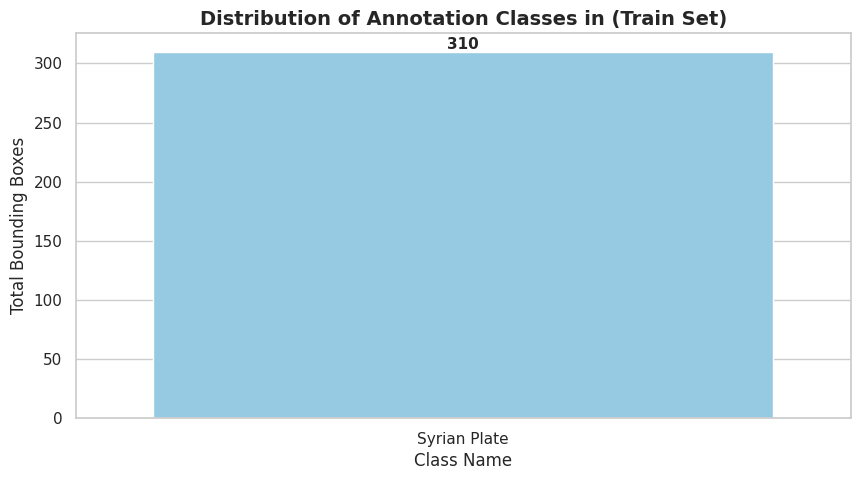


--_Classes distribution report ---
       Class  Count  Percentage
Syrian Plate    310       100.0


,Class,Count,Percentage
0,Syrian Plate,310,100.0


In [5]:
def analyze_class_distribution(base_path, class_names, split='train'):
    label_dir = Path(base_path) / split / 'labels'
    class_counts = Counter()
    total_boxes = 0
    
    for label_file in label_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
                    
    
    data = []
    for cid, count in class_counts.items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown ({cid})"
        data.append({'Class': name, 'Count': count, 'Percentage': (count / total_boxes) * 100})
        
    df_class = pd.DataFrame(data)
    
    
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x='Class', y='Count', data=df_class, color='#89CFF0')
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')
        
    plt.title(f'Distribution of Annotation Classes in ({split.capitalize()} Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Name', fontsize=12)
    plt.ylabel('Total Bounding Boxes', fontsize=12)
    plt.show()
    
    print("\n--_Classes distribution report ---")
    print(df_class.to_string(index=False))
    return df_class


class_names = {0: 'Syrian Plate'} 
analyze_class_distribution(REAL_BASE_PATH, class_names, split='train')

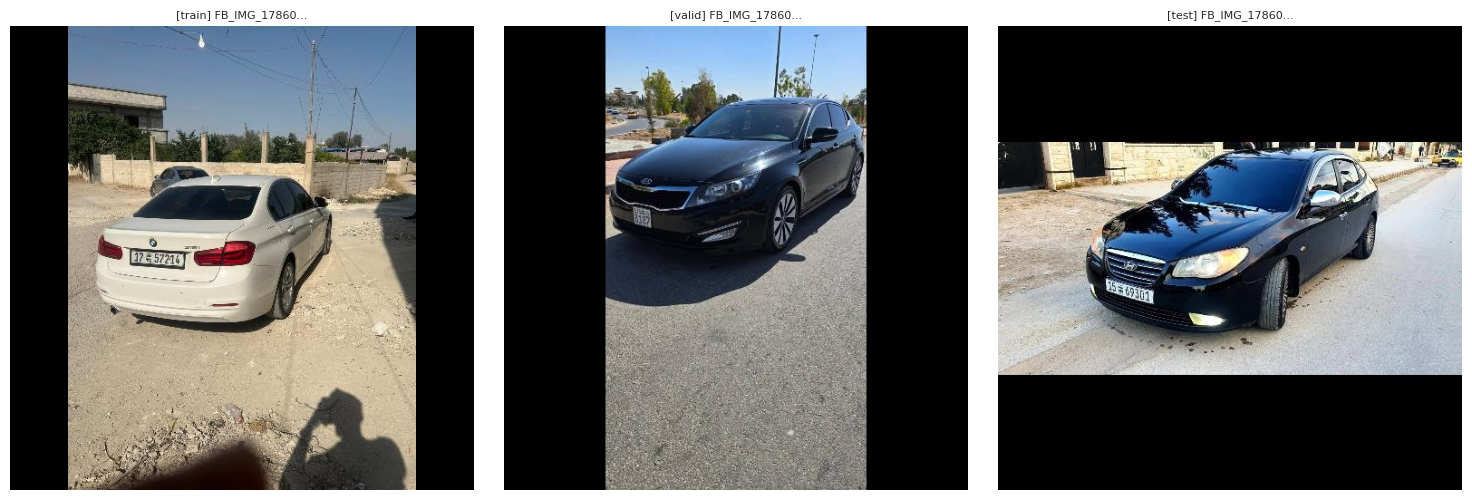

In [6]:
sample_paths = []
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(REAL_BASE_PATH, split, 'images')
    if os.path.exists(img_dir):
        files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if files:
            sample_paths.append((os.path.join(img_dir, random.choice(files)), split))

if not sample_paths:
    raise FileNotFoundError(f"No images in : {REAL_BASE_PATH}")

fig, axes = plt.subplots(1, len(sample_paths), figsize=(5 * len(sample_paths), 5))
axes_list = [axes] if len(sample_paths) == 1 else axes.flatten()

for ax, (img_path, split) in zip(axes_list, sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    img_name = os.path.basename(img_path)
    short_name = img_name if len(img_name) <= 15 else img_name[:12] + "..."
    ax.set_title(f"[{split}] {short_name}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
from ultralytics import YOLO

model = YOLO('/kaggle/input/datasets/issahasan43/plates-detector-v2yolo26n-wheights-best/best.pt')  


results = model.train(
    data='/kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26/data.yaml', 
    epochs=50,       
    imgsz=1024,       
    batch=32,    
    device = [-1,-1],
    project='Syrian_Plates_Project', 
    name='transfer_learning_run',
    patience = 10,
    lr0=0.001,       
    lrf=0.01,        
    freeze=10,
    cache=True,
    mosaic=0.0,
    optimizer = 'MuSGD',
    
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0, 1]
Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26/data.y

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50         6G      1.297     0.4541   0.005174         11       1024: 100% ━━━━━━━━━━━━ 10/10 2.3it/s 4.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all         41         41      0.891      0.999      0.953      0.641

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50         6G      1.179     0.4986   0.004437         11       1024: 100% ━━━━━━━━━━━━ 10/10 2.5it/s 4.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all         41         41      0.911          1      0.962      0.696

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       4/50         6G      1.025     0.3755   0.003849         11       1024: 100% ━━━━━━━━━━━━ 10/10 

In [8]:
best_weights = str(model.trainer.best)
model = YOLO(best_weights)

test_metrics = model.val(
    data='/kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26/data.yaml',
    split='test',
    imgsz=1024,
    batch=32,
    cache=True,
    device=[-1, -1]
)

print("\n" + "="*40 + "\n GLOBAL METRICS \n" + "="*40)
print("mAP50-95:", test_metrics.box.map)
print("mAP50:", test_metrics.box.map50)
print("mAP75:", test_metrics.box.map75)
print("Mean precision:", test_metrics.box.mp)
print("Mean recall:", test_metrics.box.mr)
print("Fitness:", test_metrics.box.fitness())

print("\n" + "="*40 + "\n PER-CLASS METRICS \n" + "="*40)
print("Class indices evaluated:", test_metrics.box.ap_class_index)
print("Per-class mAP50-95:", test_metrics.box.maps)

print("\n" + "="*40 + "\nTIMING \n" + "="*40)
print("Timing breakdown (ms/image):", test_metrics.speed)

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [1, 0]
Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:1 (Tesla T4, 14912MiB)
                                                        CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.4 ms, read: 67.4±12.4 MB/s, size: 41.4 KB)
val: Scanning /kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26/test/labels... 41 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 41/41 407.6it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/issahasan43/syrian-platesnew-only/LatestPlatesDatasetsyolo26/test is not writable, cache not saved.
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.1GB RAM): 100% ━━━━━━━━━━━━ 41/4